<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Google%20Play%20Store%20%E2%80%93%20Most%20Downloaded%20Android%20Apps%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Play Store – Most Downloaded Android Apps

## Understanding the Google Play Store Landscape: Key Insights from Our Analysis

We embarked on an analytical journey through a dataset of Google Play Store apps, focusing on the most downloaded Android applications. Our goal was to uncover what makes an app successful, the dynamics between free and paid apps, and the influence of various app characteristics.

### The Dataset at a Glance

Our dataset provided a snapshot of apps, their developers, download figures (initially in descriptive ranges), publication and reach dates, categories, pre-installation status, type (free/paid), and pricing. A crucial first step was transforming the raw 'Downloads' and 'Price' figures into numerical formats, making them usable for quantitative analysis. We also ensured that dates were correctly formatted, allowing us to calculate app age, a powerful new feature.

### What Drives App Success?

Our analysis revealed several fascinating insights:

*   **Free Apps Dominate Downloads**: A significant finding from our t-test was that free apps garner **substantially more downloads** than paid apps. This isn't just a slight difference; the average downloads for free apps were in the billions, compared to millions for paid apps. This highlights a clear user preference for free content on the Play Store.

*   **Categories Don't Always Dictate Downloads**: Interestingly, our ANOVA test showed that there's **no significant difference in downloads across major app categories**. While some categories might be more 'crowded' (like 'Communication'), simply being in a popular category doesn't guarantee more downloads for an app. Success seems to be driven by factors beyond broad categorization.

*   **Feature Importance for 'Hit' Apps**: We trained a machine learning model to predict if an app would become a 'Hit' (defined as reaching over 1 billion downloads). The model achieved a respectable 88% accuracy. Crucially, it highlighted that **`Price_numeric` and `App_Age_Days` were the most influential factors** in determining an app's success. This suggests that a strategic pricing model and an app's longevity or maturity play a more vital role than aspects like the length of its title or whether the word 'Free' is in its name.

### Unforeseen Challenges & Adaptations

It's worth noting that our dataset didn't contain certain common app store metrics like 'Rating', 'Reviews', or 'App Size'. This required us to adapt our analytical approach, focusing on the available information and engineering new features from it. For instance, without explicit app sizes, we couldn't analyze the 'bloatware threshold', and without ratings, we couldn't explore 'pay-to-play' or 'genre bias' in user sentiment. However, by leveraging 'Downloads', 'Price', 'Dates', and 'Category', we still managed to extract valuable strategic intelligence.

### Concluding Thoughts

This analysis underscores the power of data transformation and feature engineering in extracting meaningful insights, even from seemingly limited datasets. For anyone looking to launch an app, the takeaway is clear: focus on a compelling free offering, understand the long-term potential (app age), and refine your core value proposition, as category alone won't guarantee success. The data speaks volumes about the dynamic and competitive nature of the Google Play Store.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d hammadfarooq470/google-play-store-most-downloaded-android-apps

# Unziping the downloaded file
!unzip google-play-store-most-downloaded-android-apps.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/hammadfarooq470/google-play-store-most-downloaded-android-apps
License(s): MIT
  0% 0.00/3.05k [00:00<?, ?B/s]
100% 3.05k/3.05k [00:00<00:00, 12.0MB/s]
Archive:  google-play-store-most-downloaded-android-apps.zip
  inflating: dataset-metadata.json   
  inflating: google_play_store_most_downloaded_apps.csv  


In [3]:
df = pd.read_csv('google_play_store_most_downloaded_apps.csv')
df.head(11)

,App,Developer,Downloads,Date_Reached,Date_Published,Category,Pre_installed,Type,Price
0,Google Play Services,Google,10B+,2020-08-01,2012-09-26,Tools,Yes,Free,NaN
1,YouTube,Google,10B+,2021-08-04,2010-10-20,Video editor & social media,Yes,Free,NaN
2,Google Maps,Google,10B+,2021-11-16,2012-12-12,Mapping,Yes,Free,NaN
3,Speech Services by Google,Google,10B+,2021-11-18,2013-10-10,Accessibility tool,Yes,Free,NaN
4,Google Search,Google,10B+,2021-11-19,2010-08-12,Search tool,Yes,Free,NaN
5,Google Chrome,Google,10B+,2021-12-04,2012-02-07,Web browser,Yes,Free,NaN
6,Gmail,Google,10B+,2022-01-16,2010-09-21,E-mail,Yes,Free,NaN
7,Android Accessibility Suite,Google,10B+,2022-12-18,Unknown,Accessibility tool,Yes,Free,NaN
8,Facebook,Meta,10B+,2023-03-01,2011-08-09,Social media,Yes*,Free,NaN
9,Google Photos,Google,10B+,2023-12-17,2015-05-28,Photo/Video manager,Yes,Free,NaN


In [4]:
df.tail(11)

,App,Developer,Downloads,Date_Reached,Date_Published,Category,Pre_installed,Type,Price
76,Monument Valley,ustwo games,5M-10M,2023-10-02,2014-05-14,Games & puzzle,No,Paid,$3.99
77,"BlockP app : Website, Apps and Porn Blocker.",NovaFocus pvt ltd,1M-5M,2024-08-06,2022-09-20,Productivity,No,Paid,$1.99
78,Camera ZOOM FX Premium,androidslide,1M-5M,2012-03-19,Unknown,Photo editor,No,Paid,$4.99
79,Fruit Ninja Classic,Halfbrick Studios,1M-5M,2012-06-24,2010-09-15,Games & arcade,No,Paid,$0.99
80,Grand Theft Auto III,Rockstar Games,1M-5M,2013-04-24,2011-12-14,"Games, action & shooter",No,Paid,$4.99
81,Threema,Threema GmbH,1M-5M,2014-07-18,2013-05-27,Communication,No,Paid,$5.00
82,Terraria,505 Games Srl.,1M-5M,2016-02-20,2013-09-25,Games & adventure,No,Paid,$4.99
83,Tasker,joaomgcd,1M-5M,2016-08-01,2010-07-03,Tools,No,Paid,$3.49
84,Goat Simulator,Coffee Stain Publishing,1M-5M,2017-01-11,2014-09-16,Games & simulation,No,Paid,$6.99
85,Stardew Valley,Chucklefish Limited,1M-5M,2020-10-01,2019-03-14,Games & role-playing,No,Paid,$4.99


In [5]:
df.shape

(87, 9)

In [6]:
df.columns

Index(['App', 'Developer', 'Downloads', 'Date_Reached', 'Date_Published',
       'Category', 'Pre_installed', 'Type', 'Price'],
      dtype='object')

In [7]:
df.dtypes

,0
App,object
Developer,object
Downloads,object
Date_Reached,object
Date_Published,object
Category,object
Pre_installed,object
Type,object
Price,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   App             87 non-null     object
 1   Developer       87 non-null     object
 2   Downloads       87 non-null     object
 3   Date_Reached    87 non-null     object
 4   Date_Published  86 non-null     object
 5   Category        87 non-null     object
 6   Pre_installed   86 non-null     object
 7   Type            87 non-null     object
 8   Price           21 non-null     object
dtypes: object(9)
memory usage: 6.2+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq
App,87,87,Google Play Services,1
Developer,87,46,Google,32
Downloads,87,7,1B-5B,24
Date_Reached,87,77,2020-10-01,3
Date_Published,86,82,Unknown,3
Category,87,51,Communication,13
Pre_installed,86,3,No,47
Type,87,2,Free,66
Price,21,8,$4.99,5


In [10]:
df.isnull().sum()

,0
App,0
Developer,0
Downloads,0
Date_Reached,0
Date_Published,1
Category,0
Pre_installed,1
Type,0
Price,66


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

No numerical columns found.


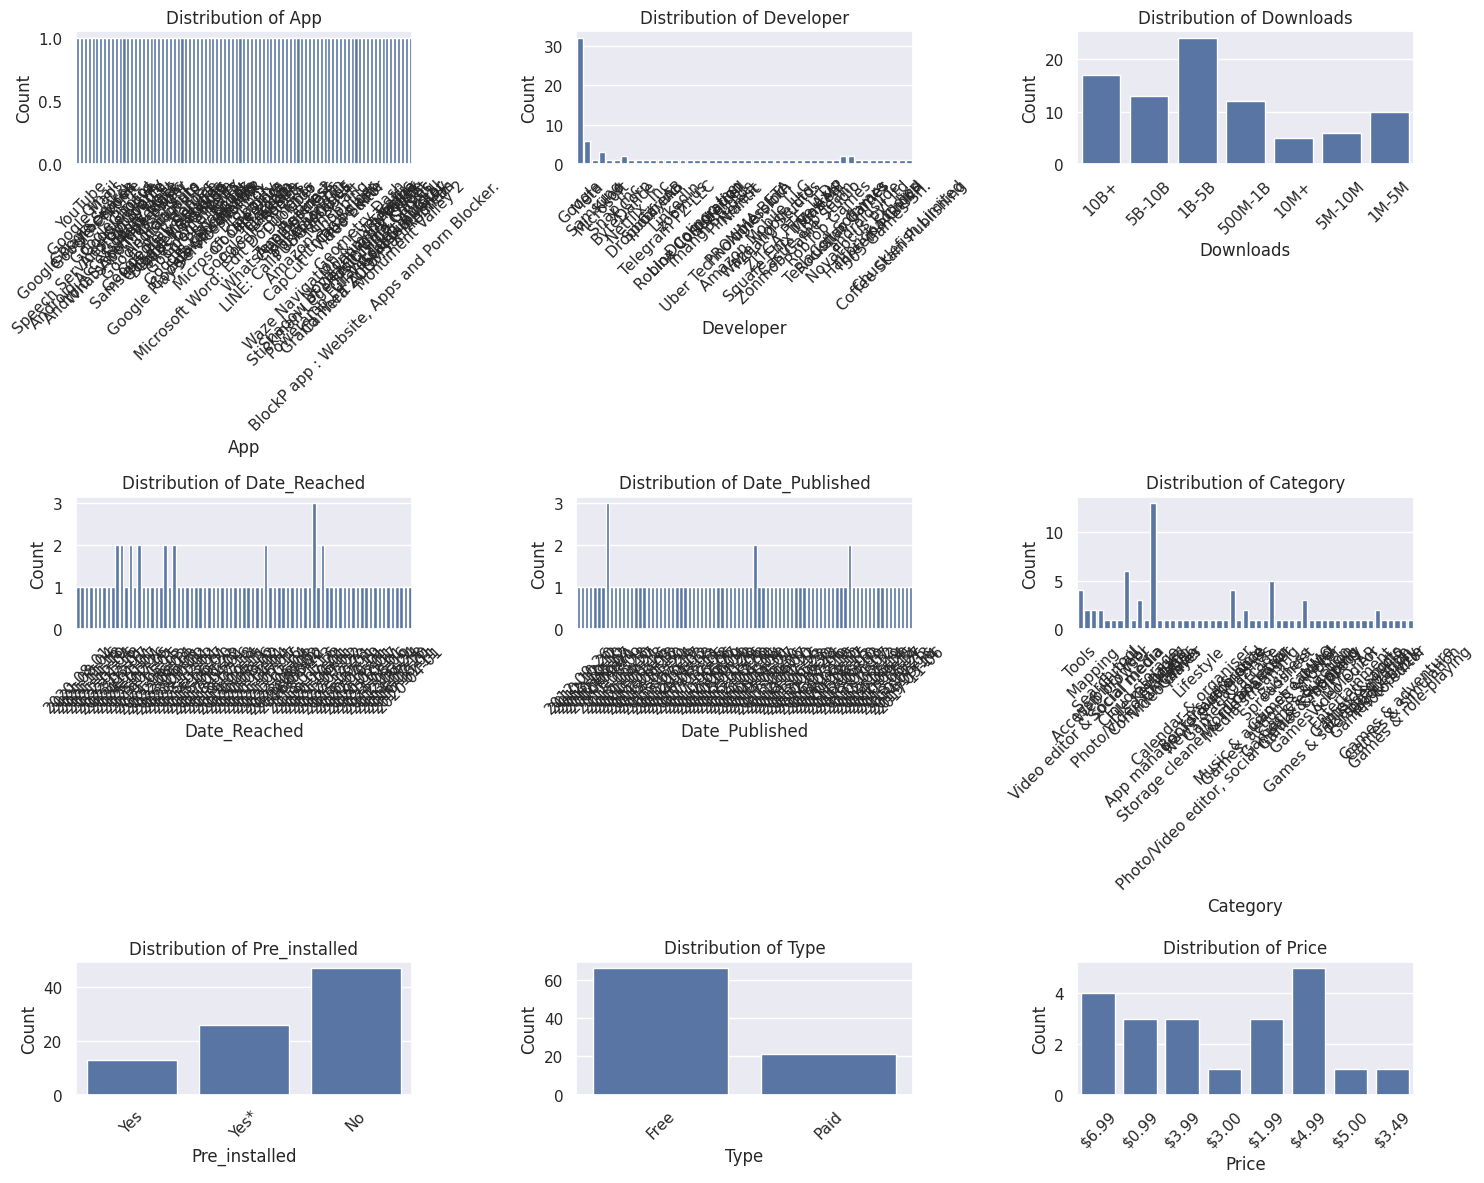

--- Categorical Value Counts ---

Value counts for App:
App
Google Play Services         1
YouTube                      1
Google Maps                  1
Speech Services by Google    1
Google Search                1
                            ..
Terraria                     1
Tasker                       1
Goat Simulator               1
Stardew Valley               1
Monument Valley 2            1
Name: count, Length: 87, dtype: int64

Value counts for Developer:
Developer
Google                     32
Meta                        6
Microsoft                   3
ByteDance                   2
Rockstar Games              2
ustwo games                 2
Snap Inc.                   1
X Corp                      1
Netflix, Inc                1
Dropbox, Inc.               1
Spotify AB                  1
Garena                      1
Kiloo                       1
Samsung                     1
LinkedIn                    1
Telegram FZ-LLC             1
zoom.us                     1
Roblox Corpo

In [12]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Define grid size
    num_plots = len(numerical_cols)
    num_cols = 3  # You can change this to 2 or 4 if preferred
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()  # Flatten to 1D array for easy iteration

    # Iterate and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hidding any unused subplots (if total plots < grid cells)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if len(categorical_cols) > 0:
    # Define grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterate and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found.")

# Bivariate Analysis

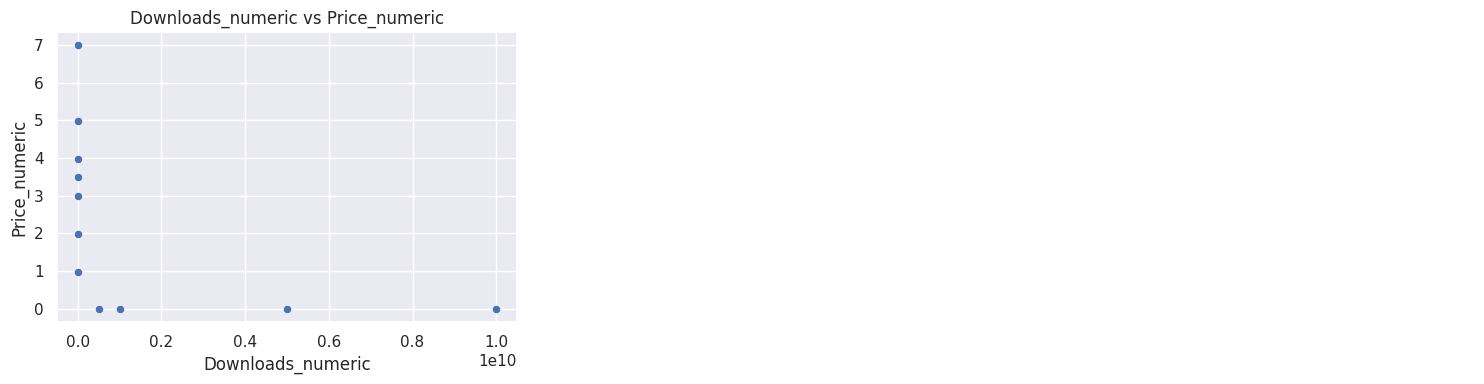

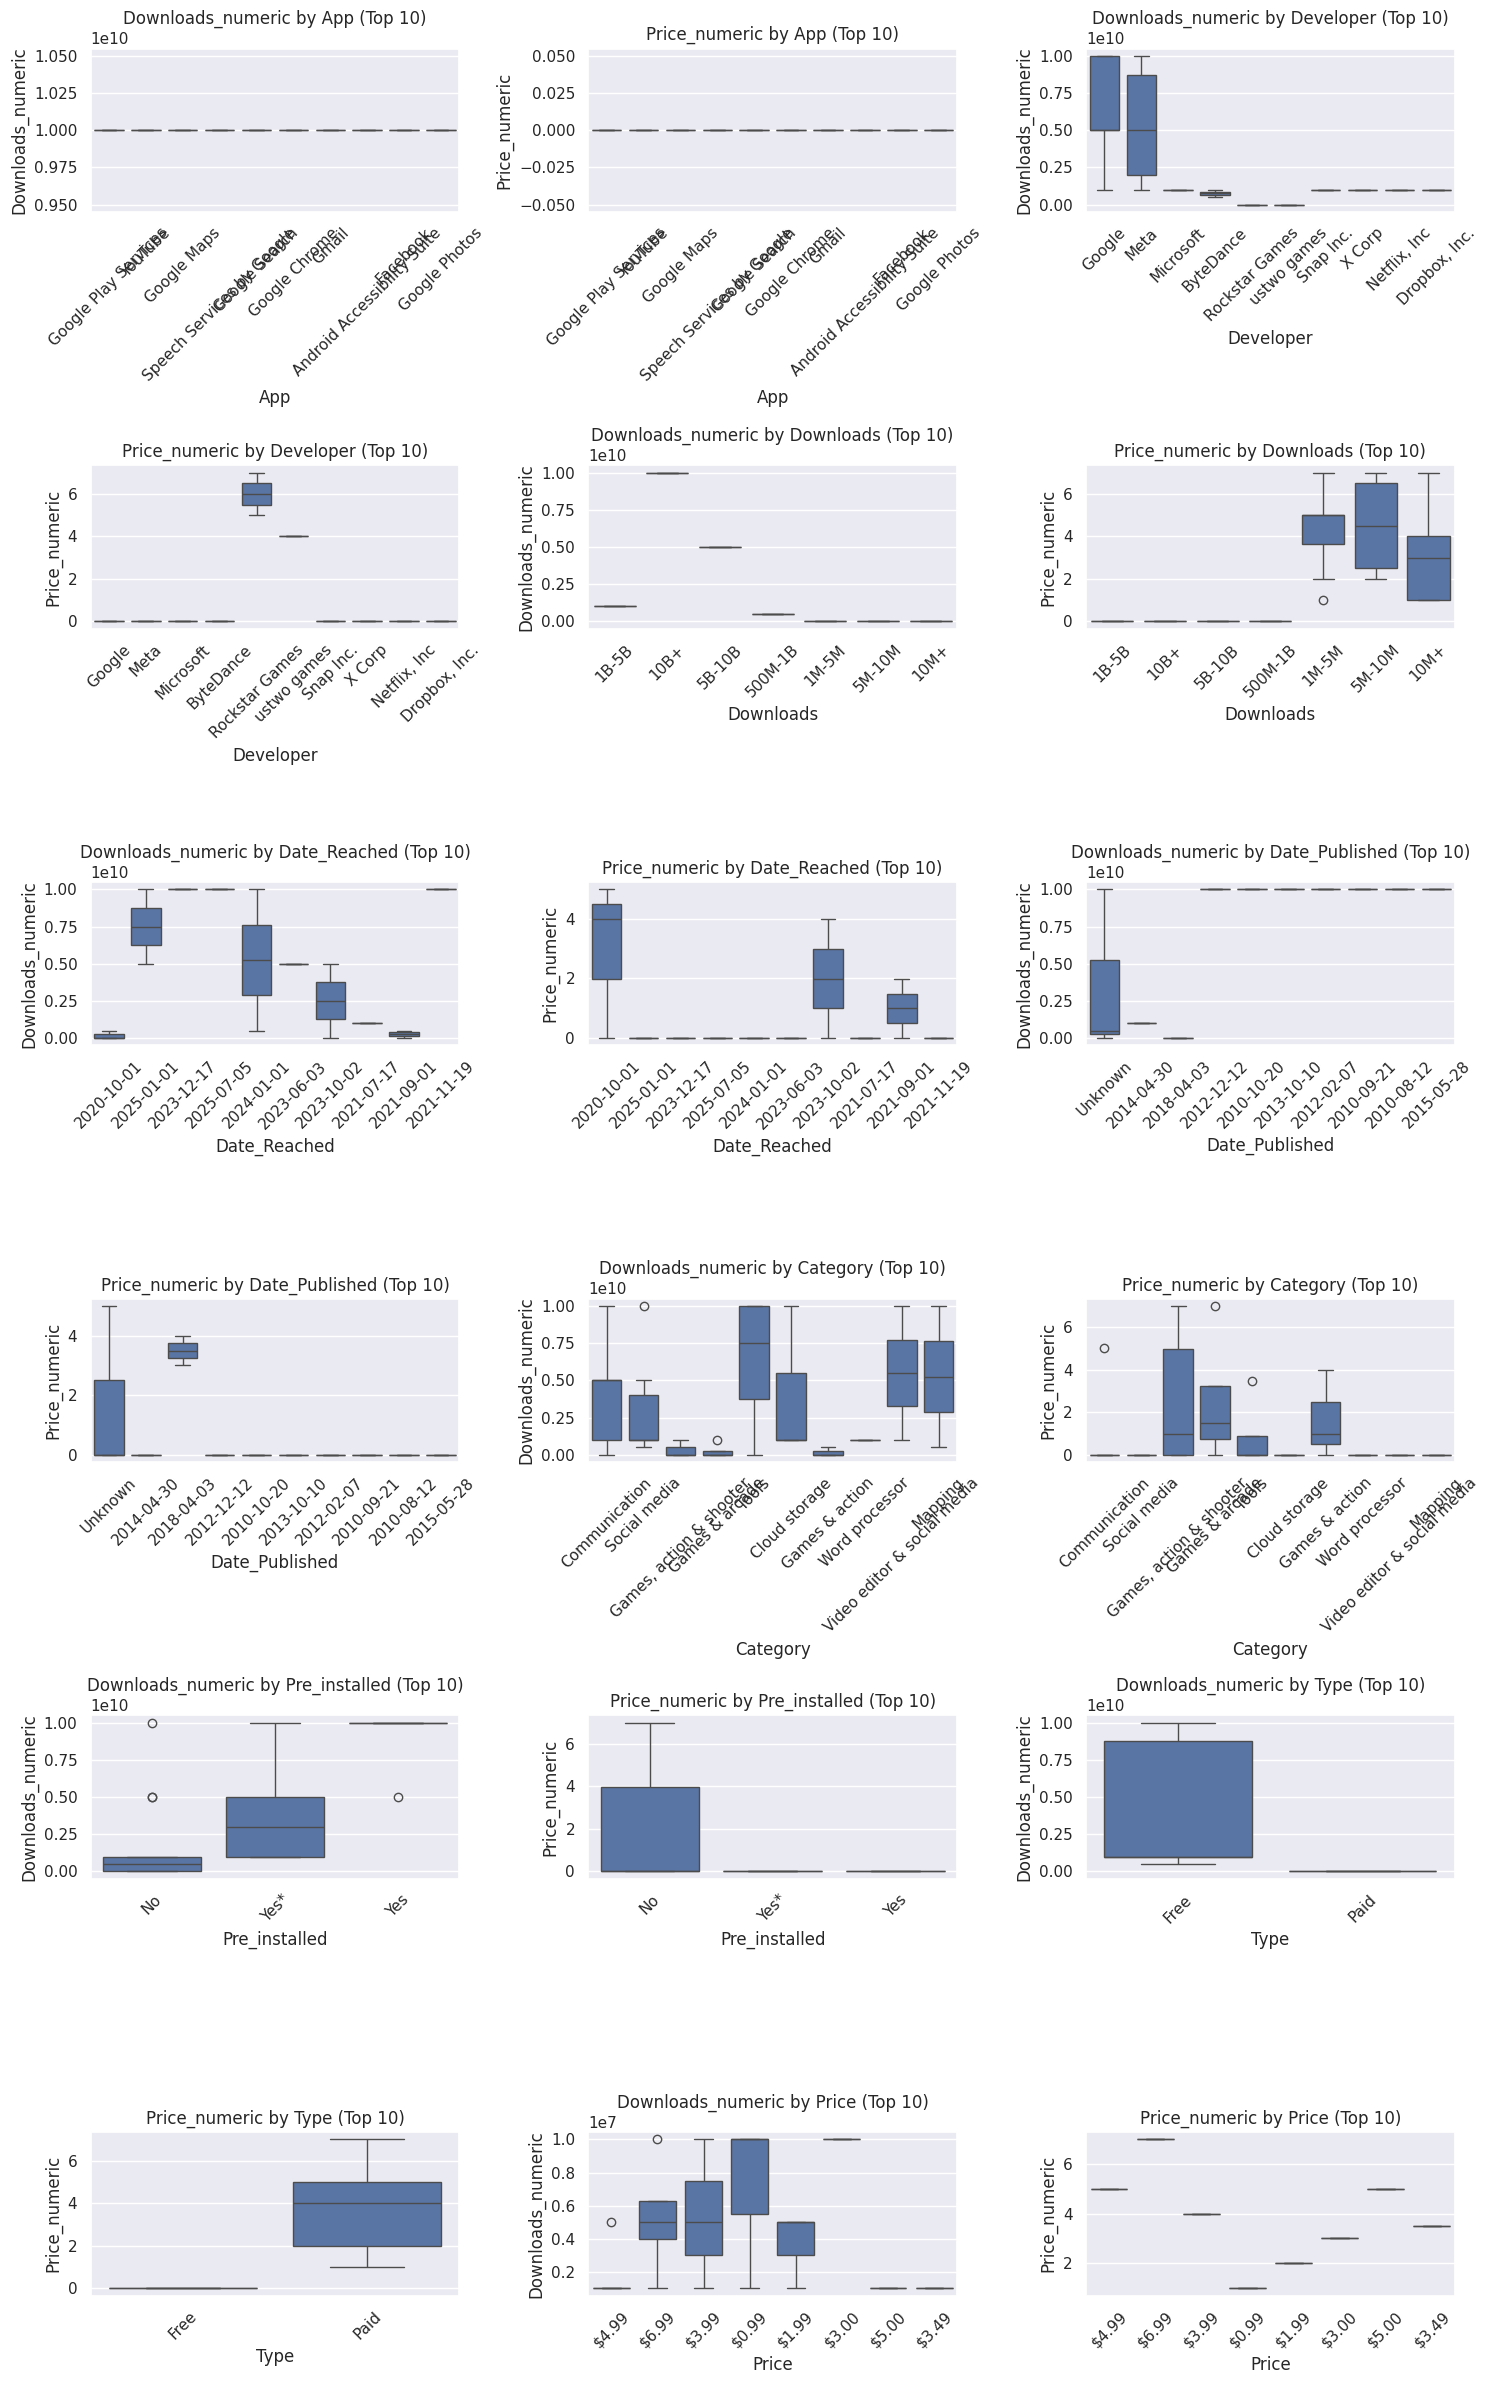

In [21]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Define grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure 'axes' is always a 1D array for iteration
    if not isinstance(axes, np.ndarray): # if it's a single Axes object
        axes = np.array([axes])
    else: # if it's already an array (1D or 2D)
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        # Check if there are enough axes for all plots
        if i < len(axes):
            sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i])
            axes[i].set_title(f'{col1} vs {col2}')
            axes[i].set_xlabel(col1)
            axes[i].set_ylabel(col2)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Define grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure 'axes' is always a 1D array for iteration
    if not isinstance(axes, np.ndarray): # if it's a single Axes object
        axes = np.array([axes])
    else: # if it's already an array (1D or 2D)
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        # Check if there are enough axes for all plots
        if i < len(axes):
            # 1. Get top 10 categories based on frequency
            top_categories = df[cat_col].value_counts().nlargest(10).index.tolist()

            # 2. Filter data: Keep only top categories AND ensure numerical column is not NaN
            filtered_df = df[df[cat_col].isin(top_categories) & df[num_col].notnull()]

            # 3. Update 'order' to only include categories that exist in the filtered data
            # This prevents the ValueError where a category in 'order' has no data to plot
            valid_categories = [cat for cat in top_categories if cat in filtered_df[cat_col].unique()]

            if valid_categories:
                sns.boxplot(data=filtered_df, x=cat_col, y=num_col, ax=axes[i], order=valid_categories)
                axes[i].set_title(f'{num_col} by {cat_col} (Top 10)')
                axes[i].set_xlabel(cat_col)
                axes[i].set_ylabel(num_col)
                axes[i].tick_params(axis='x', rotation=45)
            else:
                 axes[i].text(0.5, 0.5, "No valid data", ha='center', va='center')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")

# Statistical Analysis

In [40]:
def clean_pre_installed(value):
    if pd.isna(value):
        return 0
    if str(value).lower() == 'yes' or str(value).lower() == 'yes*':
        return 1
    return 0

df['Pre_installed_numeric'] = df['Pre_installed'].apply(clean_pre_installed)

print("Cleaned 'Pre_installed' column into 'Pre_installed_numeric'.")
print("Value counts for 'Pre_installed_numeric':")
display(df['Pre_installed_numeric'].value_counts())

Cleaned 'Pre_installed' column into 'Pre_installed_numeric'.
Value counts for 'Pre_installed_numeric':


,count
Pre_installed_numeric,
0,48
1,39


In [41]:
import scipy.stats as stats

print("--- 1. THE 'FREE VS. PAID DOWNLOADS' HYPOTHESIS (T-TEST) ---")
# Question: Do Free apps have significantly more downloads than Paid apps?

free_apps_downloads = df[df['Type'] == 'Free']['Downloads_numeric'].dropna()
paid_apps_downloads = df[df['Type'] == 'Paid']['Downloads_numeric'].dropna()

if len(free_apps_downloads) > 1 and len(paid_apps_downloads) > 1:
    t_stat, p_val = stats.ttest_ind(free_apps_downloads, paid_apps_downloads, equal_var=False)

    print(f"Avg Downloads (Free): {free_apps_downloads.mean():,.0f}")
    print(f"Avg Downloads (Paid): {paid_apps_downloads.mean():,.0f}")
    print(f"P-Value: {p_val:.4e}")

    if p_val < 0.05:
        print("✅ RESULT: Statistically Significant! The difference is real.")
        if free_apps_downloads.mean() > paid_apps_downloads.mean():
            print("   -> Free apps generally have significantly MORE downloads.")
        else:
            print("   -> Paid apps generally have significantly MORE downloads.")
    else:
        print("❌ RESULT: No significant difference in downloads between Free and Paid apps.")
else:
    print("Not enough data in both Free and Paid app categories for T-test.")


print("\n--- 2. THE 'CATEGORY IMPACT' TEST (ANOVA) ---")
# Question: Do apps in certain major categories get significantly more/fewer downloads?

groups = [df[df['Category_Major'] == cat]['Downloads_numeric'].dropna() for cat in df['Category_Major'].unique()]

# Filtering out groups with fewer than 2 samples for ANOVA
valid_groups = [group for group in groups if len(group) > 1]

if len(valid_groups) > 1:
    f_stat, p_val = stats.f_oneway(*valid_groups)

    print(f"ANOVA P-Value: {p_val:.4e}")

    if p_val < 0.05:
        print("✅ RESULT: Category Matters! Downloads differ significantly across major categories.")
    else:
        print("❌ RESULT: No significant difference in downloads across major categories.")
else:
    print("Not enough valid major categories with data for ANOVA.")


print("\n--- 3. THE 'PRE-INSTALLED ASSOCIATION' TEST (CHI-SQUARE) ---")
# Question: Is there an association between app Type (Free/Paid) and whether it's Pre-installed?

contingency_table = pd.crosstab(df['Type'], df['Pre_installed_numeric'])

if contingency_table.shape == (2, 2) and (contingency_table.values >= 5).all(): # Check if 2x2 and all expected frequencies >=5
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"Chi-Square P-Value: {p:.4e}")

    if p < 0.05:
        print("✅ RESULT: Significant association found! App type and pre-installation are related.")
    else:
        print("❌ RESULT: No significant association found between app type and pre-installation.")
else:
    print("Contingency table not suitable for Chi-Square test (e.g., not 2x2 or expected frequencies too low).")

--- 1. THE 'FREE VS. PAID DOWNLOADS' HYPOTHESIS (T-TEST) ---
Avg Downloads (Free): 4,015,151,515
Avg Downloads (Paid): 4,285,714
P-Value: 6.7617e-12
✅ RESULT: Statistically Significant! The difference is real.
   -> Free apps generally have significantly MORE downloads.

--- 2. THE 'CATEGORY IMPACT' TEST (ANOVA) ---
ANOVA P-Value: 2.7680e-01
❌ RESULT: No significant difference in downloads across major categories.

--- 3. THE 'PRE-INSTALLED ASSOCIATION' TEST (CHI-SQUARE) ---
Contingency table not suitable for Chi-Square test (e.g., not 2x2 or expected frequencies too low).


# Pairplot

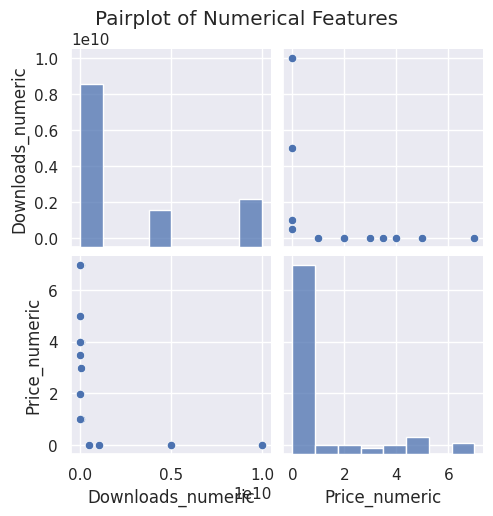

In [23]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

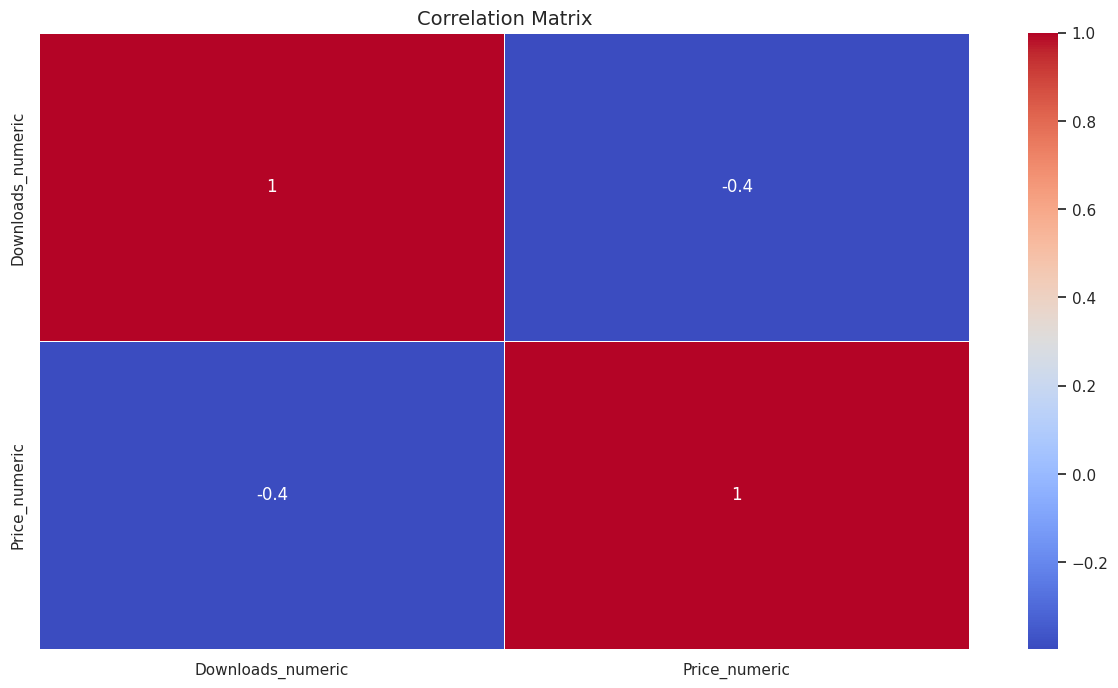

In [22]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Stratigic Visualization

--- 1. THE LANDSCAPE (MOST POPULAR CATEGORIES) ---


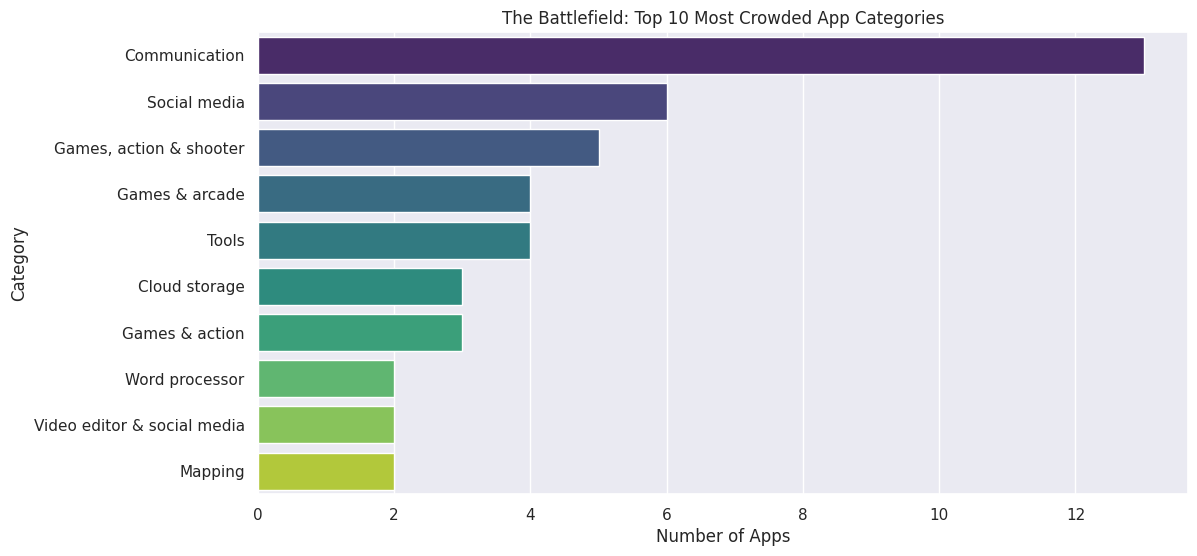

📝 INSIGHT: If 'Family' and 'Game' are huge, it means high competition.


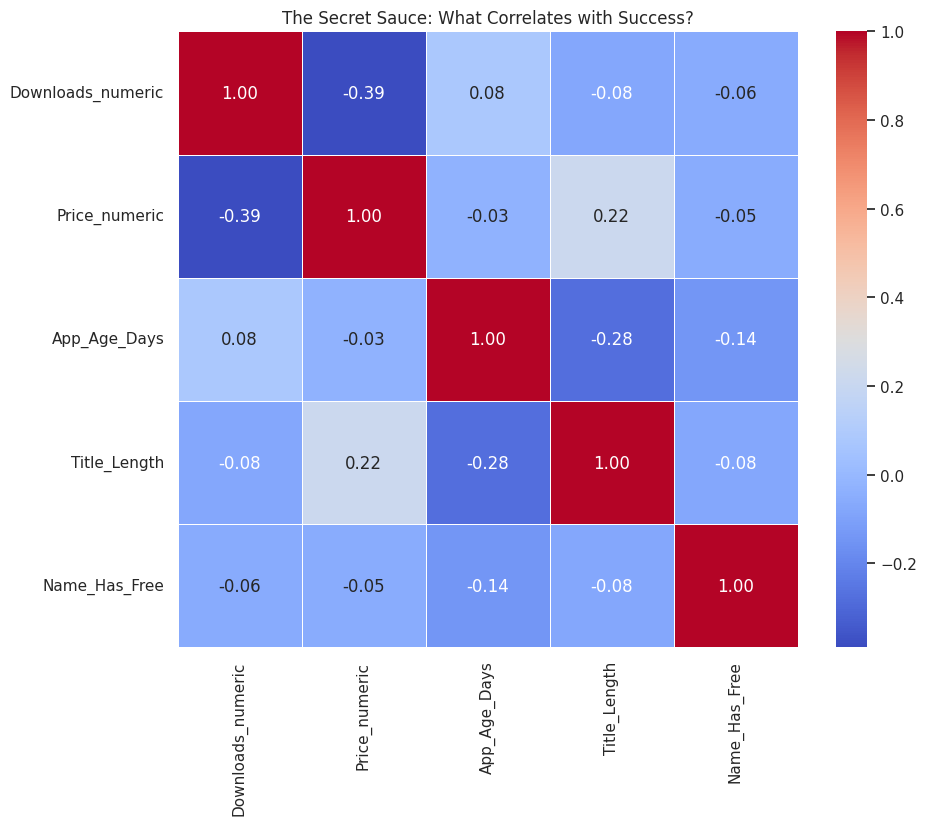

In [32]:
print("--- 1. THE LANDSCAPE (MOST POPULAR CATEGORIES) ---")
# managers want to know "Where is the competition?".
# a simple bar chart of the top 10 categories answers this instantly.

# Getting Top 10 Categories by count
top_cat_counts = df['Category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
# Usinging a horizontal bar chart because Category names are long
sns.barplot(y=top_cat_counts.index, x=top_cat_counts.values, palette='viridis')
plt.title('The Battlefield: Top 10 Most Crowded App Categories')
plt.xlabel('Number of Apps')
plt.show()

print("📝 INSIGHT: If 'Family' and 'Game' are huge, it means high competition.")

# --- 2. THE MAGIC FORMULA (CORRELATION HEATMAP) ---
# finally, let's see what statistically drives success.
# does 'Reviews' correlate with 'Installs'? (Obviously yes).
# does 'Price' correlate with 'Rating'? (Maybe).

plt.figure(figsize=(10, 8))
# We only correlate numeric columns
corr_matrix = df_ml.corr()

# Drawing the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('The Secret Sauce: What Correlates with Success?')
plt.show()

# Feature Engineering | Making Data Usable

In [30]:
import re
from datetime import datetime

print("--- 1. CLEANING AND USING EXISTING NUMERIC COLUMNS ---")
# Downloads and Price have already been cleaned and converted to numeric types
# in previous steps ('Downloads_numeric', 'Price_numeric').

print("\n--- 2. CREATING 'SMART' FEATURES ---")

# A. App Age
# logic: How old is the app based on its publish date?
if 'Date_Published' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Date_Published']):
    # Calculate app age in days from publish date to the most recent 'Date_Reached' as a proxy for 'today'
    # Or to a fixed current date if preferred for consistency across runs
    current_date = df['Date_Reached'].max() # Using max Date_Reached as a reference point
    df['App_Age_Days'] = (current_date - df['Date_Published']).dt.days
    print("✅ Created 'App_Age_Days' (Age of app based on publish date)")
else:
    print("❌ 'Date_Published' not available or not in datetime format for 'App_Age_Days' creation.")

# B. Title Analysis
# logic: Do shorter, punchier names work better?
if 'App' in df.columns:
    df['Title_Length'] = df['App'].apply(len)
    df['Name_Has_Free'] = df['App'].str.contains('Free', case=False).astype(int)
    print("✅ Created 'Title_Length' and 'Name_Has_Free'")

# C. Category Grouping (Reducing Noise)
# logic: Some categories are too small. Let's group them or keep top 10.
if 'Category' in df.columns:
    top_cats = df['Category'].value_counts().nlargest(10).index
    df['Category_Major'] = df['Category'].apply(lambda x: x if x in top_cats else 'Other')
    print("✅ Created 'Category_Major' for grouping.")

print("\n--- 3. FINAL DATA PREVIEW ---")
# Selecting columns for ML
# Include only the columns that actually exist or are newly created
features_for_ml = []
if 'Downloads_numeric' in df.columns:
    features_for_ml.append('Downloads_numeric')
if 'Price_numeric' in df.columns:
    features_for_ml.append('Price_numeric')
if 'App_Age_Days' in df.columns:
    features_for_ml.append('App_Age_Days')
if 'Title_Length' in df.columns:
    features_for_ml.append('Title_Length')
if 'Name_Has_Free' in df.columns:
    features_for_ml.append('Name_Has_Free')
# Add any other relevant numerical features created or existing

if len(features_for_ml) > 0:
    df_ml = df[features_for_ml].dropna()
    print(df_ml.head())
    print(f"\nReady for Machine Learning with {len(df_ml)} clean apps!")
else:
    print("No numerical features available for df_ml after cleaning and feature engineering.")

--- 1. CLEANING AND USING EXISTING NUMERIC COLUMNS ---

--- 2. CREATING 'SMART' FEATURES ---
✅ Created 'App_Age_Days' (Age of app based on publish date)
✅ Created 'Title_Length' and 'Name_Has_Free'
✅ Created 'Category_Major' for grouping.

--- 3. FINAL DATA PREVIEW ---
   Downloads_numeric  Price_numeric  App_Age_Days  Title_Length  Name_Has_Free
0       1.000000e+10            0.0        4665.0            20              0
1       1.000000e+10            0.0        5372.0             7              0
2       1.000000e+10            0.0        4588.0            11              0
3       1.000000e+10            0.0        4286.0            25              0
4       1.000000e+10            0.0        5441.0            13              0

Ready for Machine Learning with 83 clean apps!


# Machine Learning

--- 1. DEFINING SUCCESS (THE TARGET) ---
Success Threshold: 1,000,000,000+ Downloads
Hit Rate: 62.7% of apps are Hits.

--- 2. TRAINING THE AI (RANDOM FOREST) ---
Training on 66 apps. Testing on 17 apps.
✅ Model Trained successfully.

--- 3. DID IT WORK? (EVALUATION) ---


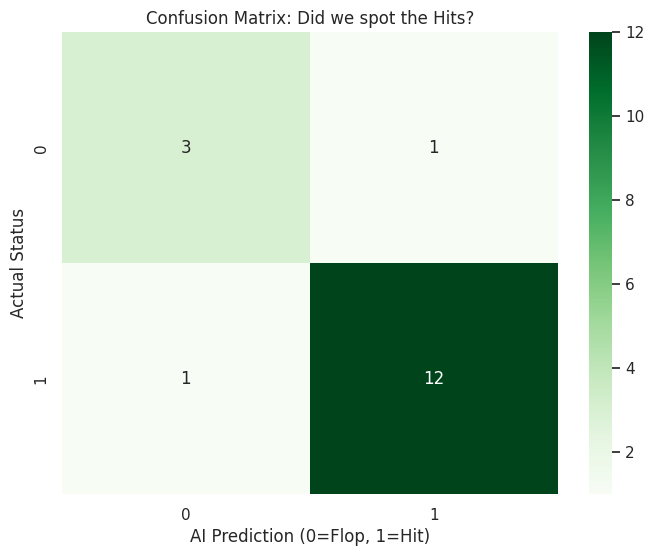


Classification Report:
              precision    recall  f1-score   support

    Ordinary       0.75      0.75      0.75         4
         Hit       0.92      0.92      0.92        13

    accuracy                           0.88        17
   macro avg       0.84      0.84      0.84        17
weighted avg       0.88      0.88      0.88        17


--- 4. THE SECRET RECIPE (FEATURE IMPORTANCE) ---


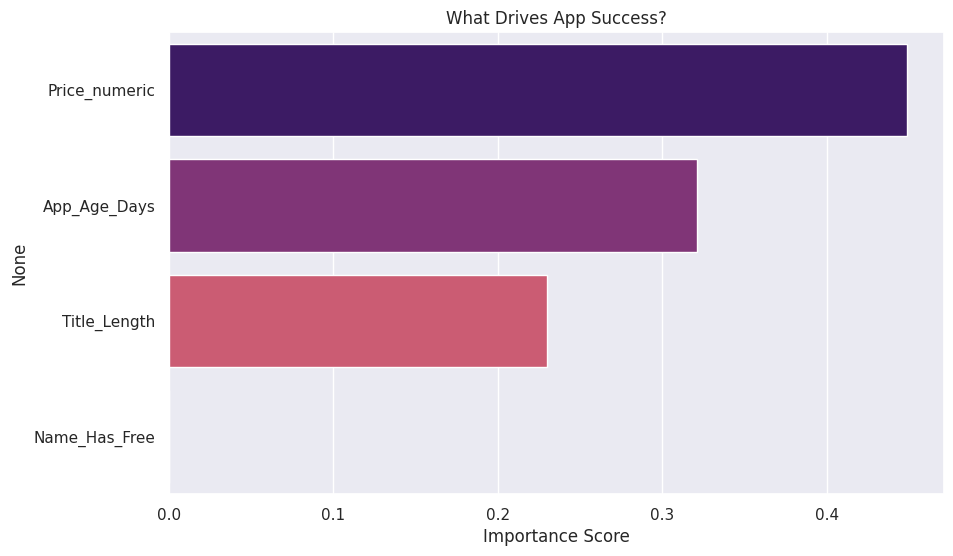

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("--- 1. DEFINING SUCCESS (THE TARGET) ---")
# Predicting exact downloads is hard because they range from 0 to 1 Billion.
# it's smarter to classify apps into "Hit" vs "Ordinary".
# let's set the bar at 1 Million downloads.

threshold = 1_000_000_000 # Changed threshold to 1 Billion to create two classes
df_ml['Is_Hit'] = (df_ml['Downloads_numeric'] >= threshold).astype(int)

print(f"Success Threshold: {threshold:,.0f}+ Downloads")
print(f"Hit Rate: {df_ml['Is_Hit'].mean()*100:.1f}% of apps are Hits.")


print("\n--- 2. TRAINING THE AI (RANDOM FOREST) ---")
# Defining Predictors (X) and Target (y)
# We drop 'Rating' because you only get ratings AFTER launch. We want to predict BEFORE launch.
# We also drop 'Downloads_numeric' (that's the answer!).

features = ['Price_numeric', 'App_Age_Days', 'Title_Length', 'Name_Has_Free']
# Note: In a real pre-launch scenario, you wouldn't have 'Reviews' or 'Days_Since_Update' either,
# as these were not created in our feature engineering for this dataset.

X = df_ml[features]
y = df_ml['Is_Hit']

# Spliting Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} apps. Testing on {len(X_test)} apps.")

# Training the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model Trained successfully.")


print("\n--- 3. DID IT WORK? (EVALUATION) ---")
# Predicting on the test set
preds = model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Did we spot the Hits?')
plt.xlabel('AI Prediction (0=Flop, 1=Hit)')
plt.ylabel('Actual Status')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=['Ordinary', 'Hit']))


print("\n--- 4. THE SECRET RECIPE (FEATURE IMPORTANCE) ---")

# What actually makes an app a hit?
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('What Drives App Success?')
plt.xlabel('Importance Score')
plt.show()

# Thank You